In [8]:
from PIL import Image


In [9]:
!pip install torch torchvision transformers pillow

from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image
import requests

# Load the model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Load an image
from google.colab import files
uploaded = files.upload()  # pick your image
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

# Define your query
text_query = ["dark green tree"]

# Preprocess and run
inputs = processor(text=text_query, images=image, return_tensors="pt")
outputs = model(**inputs)

# outputs now has predicted boxes and labels


Saving free-nature-images.jpg to free-nature-images (1).jpg


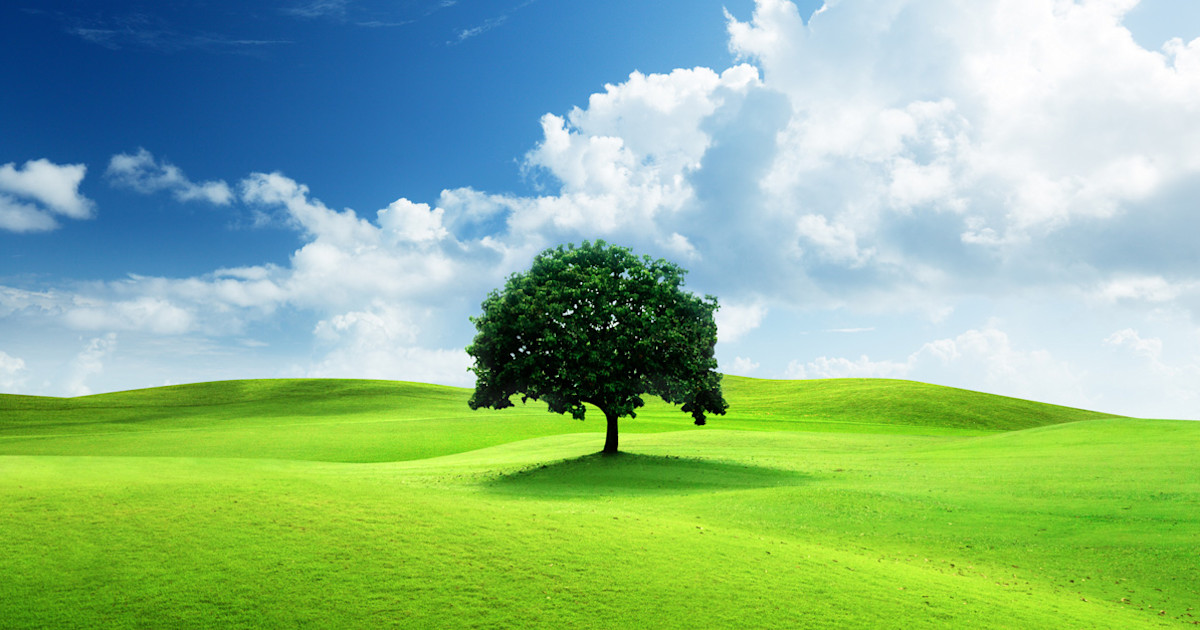

In [10]:
from PIL import Image
from IPython.display import display  # <- Colab-friendly display

# Replace with your uploaded image filename
image_path = "free-nature-images.jpg"

# Open and convert to RGB
image = Image.open(image_path).convert("RGB")

# Display inline in Colab
display(image)


In [11]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import torch

# Load the processor and model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Define your text query
text_query = ["dark green tree"]  # can be a list of multiple queries

# Preprocess image and text
inputs = processor(text=text_query, images=image, return_tensors="pt")

# Forward pass
outputs = model(**inputs)

# The outputs contain bounding boxes, scores, and labels
# You can print them or visualize next
print(outputs)


OwlViTObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[ -7.9455],
         [-10.0043],
         [ -9.2523],
         [ -8.9395],
         [ -8.2845],
         [ -9.8915],
         [ -8.1322],
         [ -9.1358],
         [ -9.0178],
         [ -8.4801],
         [ -7.9643],
         [ -8.0927],
         [ -7.6021],
         [ -8.5678],
         [ -8.4864],
         [ -9.0123],
         [ -9.5396],
         [ -8.6245],
         [ -9.1107],
         [ -9.4599],
         [ -8.3529],
         [ -8.7473],
         [ -9.1461],
         [-11.7149],
         [ -8.4492],
         [ -9.2189],
         [ -8.3735],
         [ -7.9021],
         [ -9.4081],
         [ -9.7070],
         [ -8.3463],
         [ -8.9212],
         [ -8.8157],
         [ -8.7739],
         [-12.0333],
         [-10.8466],
         [-10.2531],
         [ -9.3670],
         [ -9.4389],
         [ -8.5135],
         [ -8.9704],
         [-10.5875],
         [-11.7967],
         [-10.9861],
         [-11.

In [12]:
import torch

# Boxes
boxes = outputs.pred_boxes[0]  # shape: [num_boxes, 4]

# Scores and labels
probs = outputs.logits[0].softmax(-1)  # softmax over classes
scores, labels = probs.max(-1)          # get max probability and corresponding class index

# If you want class names (assuming using processor.tokenizer)
classes = [processor.tokenizer.decode([label]) for label in labels]

# Print first 5 predictions for sanity check
for i in range(5):
    print(f"Box: {boxes[i]}, Class: {classes[i]}, Score: {scores[i].item():.2f}")


Box: tensor([0.0750, 0.0667, 0.1492, 0.1351], grad_fn=<SelectBackward0>), Class: !, Score: 1.00
Box: tensor([0.1415, 0.0512, 0.2330, 0.1006], grad_fn=<SelectBackward0>), Class: !, Score: 1.00
Box: tensor([0.1118, 0.0233, 0.0594, 0.0422], grad_fn=<SelectBackward0>), Class: !, Score: 1.00
Box: tensor([0.1818, 0.0294, 0.1199, 0.0594], grad_fn=<SelectBackward0>), Class: !, Score: 1.00
Box: tensor([0.3003, 0.1130, 0.6057, 0.2277], grad_fn=<SelectBackward0>), Class: !, Score: 1.00


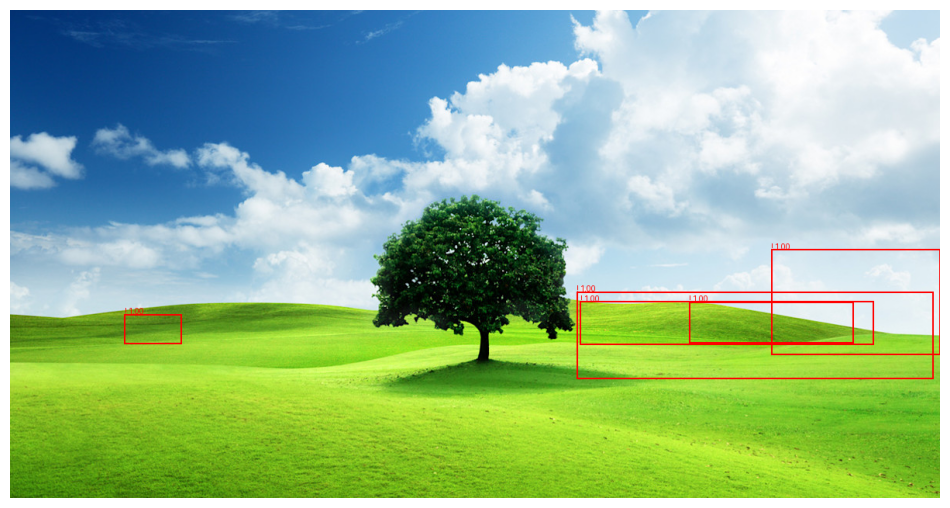

In [13]:
import torch
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# Top-k boxes to visualize
top_k = 5
threshold = 0.3  # confidence threshold

# OwlViT outputs
boxes = outputs.pred_boxes[0]         # [num_boxes, 4]
logits = outputs.logits[0]            # [num_boxes, num_classes]

# Compute scores and labels
scores, labels = torch.max(torch.softmax(logits, dim=-1), dim=-1)
indices = torch.argsort(scores, descending=True)[:top_k]

image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)
W, H = image.size

# Optional font
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

for i in indices:
    score = scores[i].item()
    if score < threshold:
        continue
    label_idx = labels[i].item()
    cls_name = processor.tokenizer.convert_ids_to_tokens([label_idx])[0]

    cx, cy, w, h = boxes[i].tolist()
    x0 = max((cx - w/2) * W, 0)
    y0 = max((cy - h/2) * H, 0)
    x1 = min((cx + w/2) * W, W)
    y1 = min((cy + h/2) * H, H)

    # Skip invalid boxes
    if x1 <= x0 or y1 <= y0:
        continue

    draw.rectangle([x0, y0, x1, y1], outline="red", width=2)
    draw.text((x0, y0-10), f"{cls_name} {score:.2f}", fill="red", font=font)

plt.figure(figsize=(12,8))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()


This notebook modifies the baseline OWL-ViT implementation by improving the text prompt specificity. Instead of using generic queries such as “tree,” we experiment with more descriptive prompts (e.g., “tall green tree,” “leafy tree trunk,” or “small green bush”). OWL-ViT relies heavily on language–vision alignment, so providing more detailed text guidance allows the model to narrow its interpretation of what object it should search for in the image.

The purpose of this modification is to evaluate how prompt engineering affects object localization quality. By making the descriptions more precise, the model reduces ambiguity and produces fewer irrelevant bounding boxes. This technique increases the likelihood of drawing boxes around the correct object rather than unrelated regions of the image. This step highlights how OWL-ViT behaves similarly to other text-conditioned models where prompt clarity directly influences output accuracy.